# Homogeneous Viscoelastic Love Numbers: Love (1911)

A homogeneous, incompressible, self-gravitating sphere has closed-form degree-2 Love numbers (Love 1911; for a viscoelastic body by the correspondence principle, e.g. Efroimsky 2012):

$$k_2 = \frac{3/2}{1 + \bar{\mu}}, \qquad h_2 = \frac{5/2}{1 + \bar{\mu}}, \qquad l_2 = \frac{3/4}{1 + \bar{\mu}}, \qquad \bar{\mu} = \frac{19\,\tilde{\mu}(\omega)}{2 \rho g R},$$

where $\tilde{\mu}(\omega)$ is the complex shear modulus of the rheology at the forcing frequency. They assume a static response (no inertia). This benchmark compares TidalPy's radial solver against them for a Maxwell body the size of Io, across rigidity and forcing frequency, with both solution methods:

- the propagation matrix, which solves the static incompressible problem the closed form describes;
- the shooting method, which integrates the equations numerically and, for an incompressible body, needs a dynamic layer and the Kamata et al. (2015) starting conditions. Its inertia term, of relative size $\omega^2 R / g$, is negligible at low frequency, so there the two problems coincide.

The last section shows where a compressible homogeneous body departs from the incompressible answer, and why its static response becomes ill-conditioned when the body is nearly fluid.

References: Love, A. E. H. (1911), *Some Problems of Geodynamics*, Cambridge University Press. Efroimsky, M. (2012), ApJ 746, 150. Kamata, S., Kuramoto, K., and Iwamori, H. (2015), JGR Planets 120, 1528.

In [1]:
%matplotlib inline
import math

import numpy as np
import matplotlib.pyplot as plt

from TidalPy.constants import G
from TidalPy.rheology_x import Maxwell
from TidalPy.structures_x import build_world

RADIUS = 1.8216e6                  # [m]
DENSITY = 3528.0                   # [kg m-3]
MASS = 4.0 / 3.0 * math.pi * RADIUS**3 * DENSITY
GRAVITY = G * MASS / RADIUS**2
RHO_G_R = DENSITY * GRAVITY * RADIUS
IO_FREQUENCY = 2.0 * math.pi / (1.769 * 86400.0)    # [rad s-1]
MAXWELL = Maxwell()


def closed_form(shear, viscosity, frequency):
    "Love (1911) k2, h2, l2 of a homogeneous incompressible Maxwell sphere."
    mu_bar = 19.0 * MAXWELL.calc_complex_modulus(shear, viscosity, frequency) / (2.0 * RHO_G_R)
    return 1.5 / (1.0 + mu_bar), 2.5 / (1.0 + mu_bar), 0.75 / (1.0 + mu_bar)


def homogeneous_world(shear, viscosity, bulk, static, incompressible):
    world = build_world({
        "schema_version": "0.2.0", "name": "homogeneous", "type": "terrestrial", "radius_m": RADIUS, "mass_kg": MASS,
        "layers": {"body": {
            "class": "solidliquid", "layer_index": 0, "radius_fraction": 1.0, "is_tidal": True,
            "is_static": static, "is_incompressible": incompressible,
            "material": {"model": "constant", "reference_density_kg_m3": DENSITY,
                         "shear_modulus_static_pa": shear, "bulk_modulus_static_pa": bulk,
                         "shear_viscosity": {"model": "constant", "reference_viscosity_pas": viscosity},
                         "partial_melt": {"model": "off"}},
            "shear_rheology": {"model": "maxwell"}, "bulk_rheology": {"model": "elastic"}}}})
    world.solve_eos()
    return world


def solve(method, shear, viscosity, frequency, bulk=None):
    "k2, h2, l2 and the surface-system rcond from one of the three set-ups used below."
    if method == "propagation matrix":
        world = homogeneous_world(shear, viscosity, 1e4 * shear, static=True, incompressible=True)
        world.solve_love_numbers(frequency=frequency, love_method="propagation_matrix", warnings=False)
    elif method == "shooting":
        world = homogeneous_world(shear, viscosity, 1e4 * shear, static=False, incompressible=True)
        world.solve_love_numbers(frequency=frequency, love_method="radial_solver", use_kamata=True, warnings=False)
    else:   # compressible, static, with the given bulk modulus
        world = homogeneous_world(shear, viscosity, bulk, static=True, incompressible=False)
        world.solve_love_numbers(frequency=frequency, love_method="radial_solver", warnings=False)
    return (complex(world.love_number_k), complex(world.love_number_h), complex(world.love_number_l),
            world.love_surface_rcond)


print(f"rho g R = {RHO_G_R:.3e} Pa")

rho g R = 1.155e+10 Pa


## Across Rigidity

Holding $\omega\eta$ fixed at Io's forcing frequency and $\eta = 10^{16}$ Pa s, the shear modulus is swept from a nearly fluid body ($\mu \ll \rho g R \approx 1.2 \times 10^{10}$ Pa) to a rigid one. The propagation matrix reproduces the closed-form $k_2$ to about $10^{-14}$ at every rigidity, and $h_2$ and $l_2$ to better than $10^{-6}$ (their worst case is the most nearly fluid body). The shooting method is run at a frequency of $10^{-9}$ rad s$^{-1}$ with the viscosity scaled to keep the same $\omega\eta$, so the complex modulus and the closed form are unchanged while inertia is negligible; it reproduces $k_2$ to $10^{-8}$ or better, and $h_2$ and $l_2$ to about $10^{-5}$ at the fluid end, the level set by the integration tolerances.

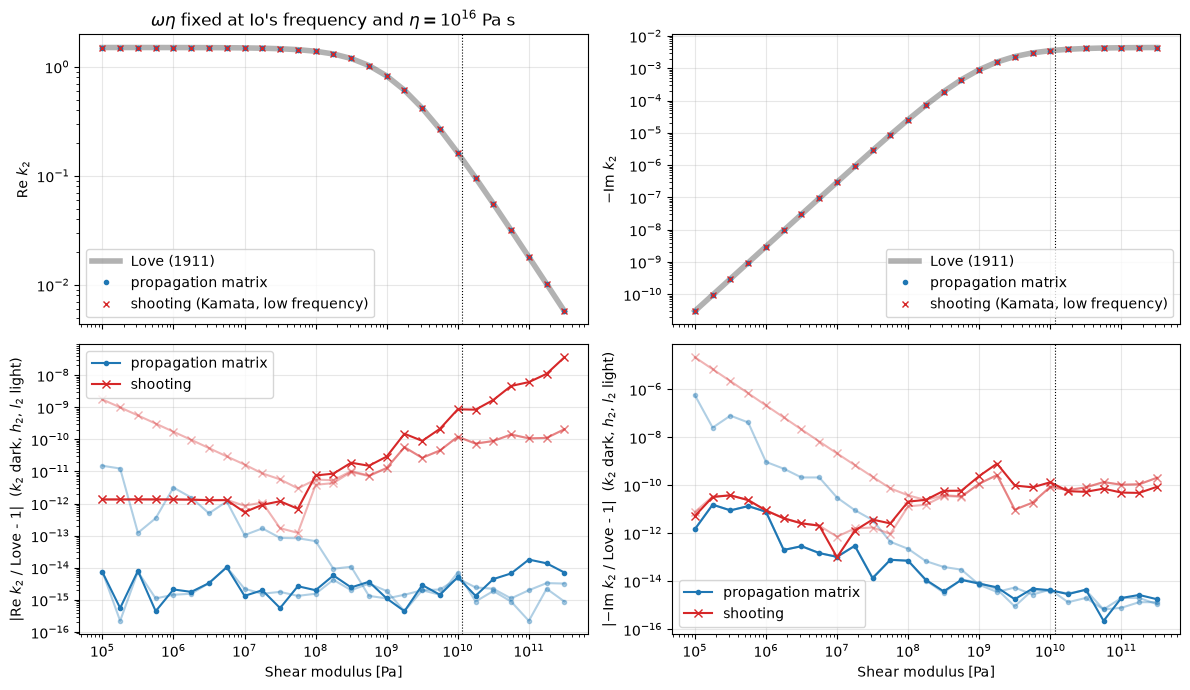

largest relative difference, k2, h2, l2 (real and imaginary parts):
  propagation matrix   real 1.5e-11   imaginary 5.6e-07
  shooting             real 3.6e-08   imaginary 2.1e-05


In [2]:
shears = np.logspace(5, 11.5, 27)
VISCOSITY = 1.0e16
LOW_FREQUENCY = 1.0e-9
low_viscosity_scale = IO_FREQUENCY / LOW_FREQUENCY

reference = np.array([closed_form(mu, VISCOSITY, IO_FREQUENCY) for mu in shears])
matrix = np.array([solve("propagation matrix", mu, VISCOSITY, IO_FREQUENCY)[:3] for mu in shears])
shooting = np.array([solve("shooting", mu, VISCOSITY * low_viscosity_scale, LOW_FREQUENCY)[:3] for mu in shears])

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for column, (part, label) in enumerate(((np.real, r"Re $k_2$"), (lambda z: -np.imag(z), r"$-$Im $k_2$"))):
    ax = axes[0, column]
    ax.loglog(shears, part(reference[:, 0]), "k-", lw=4, alpha=0.3, label="Love (1911)")
    ax.loglog(shears, part(matrix[:, 0]), "C0.", label="propagation matrix")
    ax.loglog(shears, part(shooting[:, 0]), "C3x", ms=5, label="shooting (Kamata, low frequency)")
    ax.set_ylabel(label)
    ax.legend()
    ax_err = axes[1, column]
    for values, style, name in ((matrix, "C0.-", "propagation matrix"), (shooting, "C3x-", "shooting")):
        for index, love in enumerate("khl"):
            error = np.maximum(np.abs(part(values[:, index]) / part(reference[:, index]) - 1.0), 1e-17)
            ax_err.loglog(shears, error, style, alpha=1.0 if index == 0 else 0.35,
                          label=f"{name}" if index == 0 else None)
    ax_err.set_xlabel("Shear modulus [Pa]")
    ax_err.set_ylabel(f"|{label} / Love - 1|  ($k_2$ dark, $h_2$, $l_2$ light)")
    ax_err.legend()
for ax in axes.flat:
    ax.axvline(RHO_G_R, color="k", lw=0.8, ls=":")
    ax.grid(alpha=0.3)
axes[0, 0].set_title(r"$\omega\eta$ fixed at Io's frequency and $\eta = 10^{16}$ Pa s")
plt.tight_layout()
plt.show()

print("largest relative difference, k2, h2, l2 (real and imaginary parts):")
for name, values in (("propagation matrix", matrix), ("shooting", shooting)):
    worst = max(np.max(np.abs(values[:, i].real / reference[:, i].real - 1)) for i in range(3))
    worst_im = max(np.max(np.abs(values[:, i].imag / reference[:, i].imag - 1)) for i in range(3))
    print(f"  {name:20s} real {worst:.1e}   imaginary {worst_im:.1e}")

## Across Forcing Frequency: the Maxwell Absorption Peak

At a fixed rigidity of 60 GPa, the viscosity sweep moves the forcing through the body's Maxwell relaxation. When $\mu \gg \rho g R$, $-\mathrm{Im}\,k_2$ peaks near $\eta \approx 2 \rho g R / (19 \omega)$, far below the viscosity $\mu/\omega$ at which the Maxwell time equals the forcing period: for a body this large, self-gravity rather than the shear modulus sets where the dissipation peaks. The propagation matrix follows the closed form across the peak.

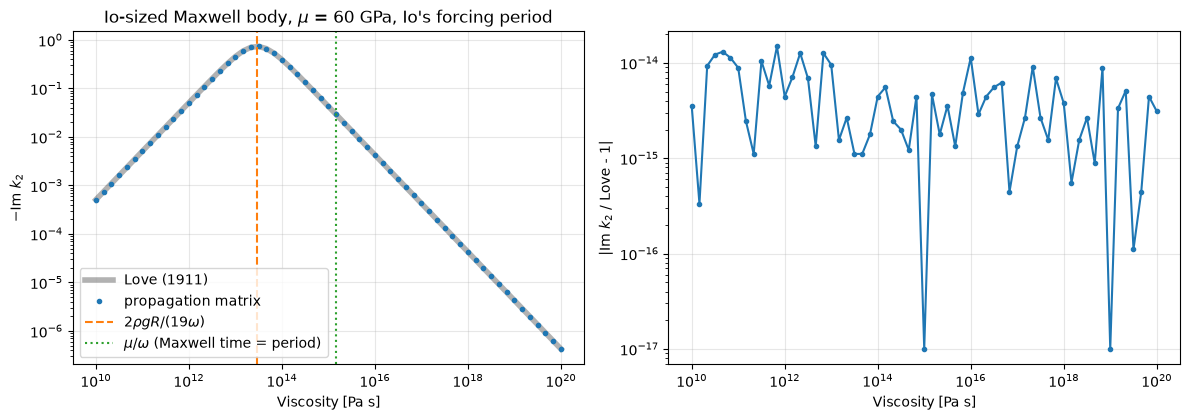

peak of -Im k2 at eta = 3.16e+13 Pa s; 2 rho g R / (19 omega) = 2.96e+13; mu / omega = 1.46e+15


In [3]:
SHEAR = 6.0e10
viscosities = np.logspace(10, 20, 61)
reference = np.array([closed_form(SHEAR, eta, IO_FREQUENCY)[0] for eta in viscosities])
matrix = np.array([solve("propagation matrix", SHEAR, eta, IO_FREQUENCY)[0] for eta in viscosities])

peak_estimate = 2.0 * RHO_G_R / (19.0 * IO_FREQUENCY)
fig, (ax, ax_err) = plt.subplots(1, 2, figsize=(12, 4.3))
ax.loglog(viscosities, -reference.imag, "k-", lw=4, alpha=0.3, label="Love (1911)")
ax.loglog(viscosities, -matrix.imag, "C0.", label="propagation matrix")
ax.axvline(peak_estimate, color="C1", ls="--", label=r"$2\rho g R / (19\omega)$")
ax.axvline(SHEAR / IO_FREQUENCY, color="C2", ls=":", label=r"$\mu / \omega$ (Maxwell time = period)")
ax.set_xlabel("Viscosity [Pa s]")
ax.set_ylabel(r"$-$Im $k_2$")
ax.set_title(r"Io-sized Maxwell body, $\mu$ = 60 GPa, Io's forcing period")
ax.legend()
ax_err.loglog(viscosities, np.maximum(np.abs(matrix.imag / reference.imag - 1), 1e-17), "C0.-")
ax_err.set_xlabel("Viscosity [Pa s]")
ax_err.set_ylabel(r"|Im $k_2$ / Love - 1|")
for axis in (ax, ax_err):
    axis.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"peak of -Im k2 at eta = {viscosities[np.argmax(-reference.imag)]:.2e} Pa s; "
      f"2 rho g R / (19 omega) = {peak_estimate:.2e}; mu / omega = {SHEAR / IO_FREQUENCY:.2e}")

## Inertia at the Forcing Frequency

At Io's own forcing frequency the dynamic, incompressible shooting solve differs from the static closed form by about $5 \times 10^{-5}$ for this rigid body. That difference is physical: it is the inertia of the deforming body, a fraction of $\omega^2 R / g$, which the static closed form leaves out. Lowering the frequency (and scaling the viscosity to keep $\omega\eta$ fixed) makes it fall as $\omega^2$ until it reaches the integration tolerance.

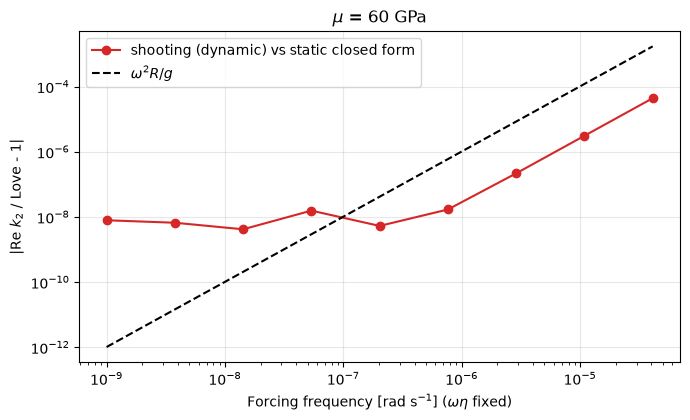

In [4]:
frequencies = np.logspace(-9, np.log10(IO_FREQUENCY), 9)
differences = []
for frequency in frequencies:
    viscosity = VISCOSITY * IO_FREQUENCY / frequency
    k2 = solve("shooting", SHEAR, viscosity, frequency)[0]
    differences.append(abs(k2.real / closed_form(SHEAR, viscosity, frequency)[0].real - 1))
differences = np.array(differences)
inertia = frequencies**2 * RADIUS / GRAVITY

fig, ax = plt.subplots(figsize=(7, 4.3))
ax.loglog(frequencies, differences, "C3o-", label="shooting (dynamic) vs static closed form")
ax.loglog(frequencies, inertia, "k--", label=r"$\omega^2 R / g$")
ax.set_xlabel(r"Forcing frequency [rad s$^{-1}$] ($\omega\eta$ fixed)")
ax.set_ylabel(r"|Re $k_2$ / Love - 1|")
ax.set_title(r"$\mu$ = 60 GPa")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## A Compressible Homogeneous Body

With a finite bulk modulus the problem is different, and the incompressible closed form is only its limit as $K/\mu \to \infty$. Down to $\mu \approx 10^{7}$ Pa the static compressible body with $K = 200$ GPa stays within tens of percent of the incompressible curve. Below that, its $-\mathrm{Im}\,k_2$ stops varying smoothly with $\mu$, and the result there is not reliable. A uniform-density body that is compressible is not in the adiabatic state its bulk modulus implies (its buoyancy frequency is imaginary, $N^2 = -\rho g^2 / K < 0$), and once the shear modulus is small, little resists that stratification in a static solve. The surface system's reciprocal condition number (`love_surface_rcond`) also falls.

For a homogeneous body that is meant to be nearly fluid ($\mu / \rho g R \lesssim 10^{-3}$), use the incompressible assumption, with the propagation matrix, or with the shooting method on a dynamic layer as above.

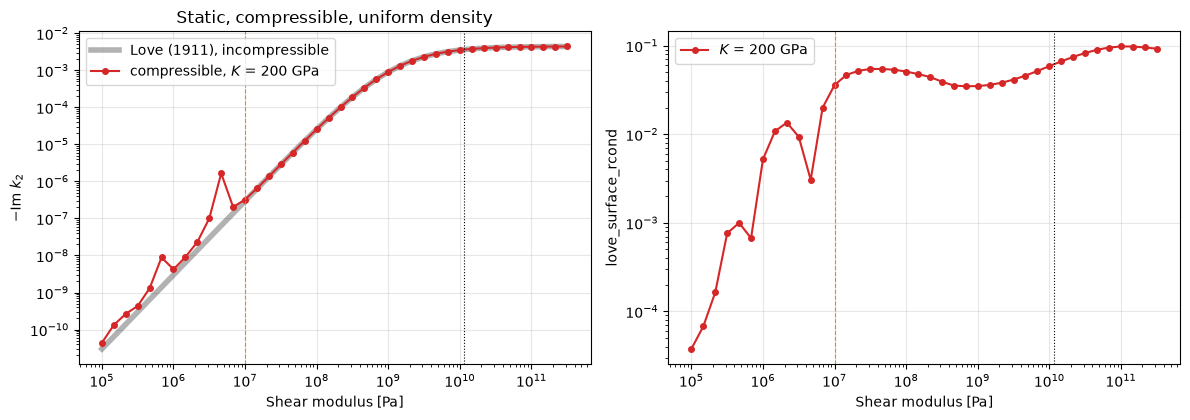

In [5]:
shears = np.logspace(5, 11.5, 40)
reference = np.array([closed_form(mu, VISCOSITY, IO_FREQUENCY)[0] for mu in shears])
compressible = [solve("compressible", mu, VISCOSITY, IO_FREQUENCY, bulk=2.0e11) for mu in shears]

fig, (ax, ax_rcond) = plt.subplots(1, 2, figsize=(12, 4.3))
ax.loglog(shears, -reference.imag, "k-", lw=4, alpha=0.3, label="Love (1911), incompressible")
ax.loglog(shears, [-c[0].imag for c in compressible], "C3o-", ms=4, label="compressible, $K$ = 200 GPa")
ax.set_xlabel("Shear modulus [Pa]")
ax.set_ylabel(r"$-$Im $k_2$")
ax.legend()
ax_rcond.loglog(shears, [c[3] for c in compressible], "C3o-", ms=4, label="$K$ = 200 GPa")
ax_rcond.set_xlabel("Shear modulus [Pa]")
ax_rcond.set_ylabel("love_surface_rcond")
ax_rcond.legend()
for axis in (ax, ax_rcond):
    axis.axvline(RHO_G_R, color="k", lw=0.8, ls=":")
    axis.axvline(1.0e7, color="C1", lw=0.8, ls="--")
    axis.grid(alpha=0.3)
ax.set_title("Static, compressible, uniform density")
plt.tight_layout()
plt.show()

## Summary

- The propagation matrix reproduces the closed-form static Love numbers of a homogeneous incompressible Maxwell sphere to rounding error, across seven decades of rigidity and across the Maxwell absorption peak.
- The shooting method, with Kamata starting conditions and a dynamic incompressible layer, agrees to its integration tolerance once inertia is negligible; at the forcing frequency the remaining difference is the physical inertia term, of size $\omega^2 R/g$.
- A static compressible uniform-density body is unreliable once it is nearly fluid ($\mu \lesssim 10^{7}$ Pa for this body); model such a body as incompressible.